In [43]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data

In [44]:
# skimage has several built-in images. Let's load a cat.
cat = data.chelsea()   # this is an RGB image (a famous photo of a cat)

print(type(cat))       # it's just a numpy array
print(cat.shape)       # (300, 451, 3) — Height, Width, Channels
print(cat.dtype)       # uint8 — values are 0-255
print(cat.min(), cat.max())

<class 'numpy.ndarray'>
(300, 451, 3)
uint8
0 231


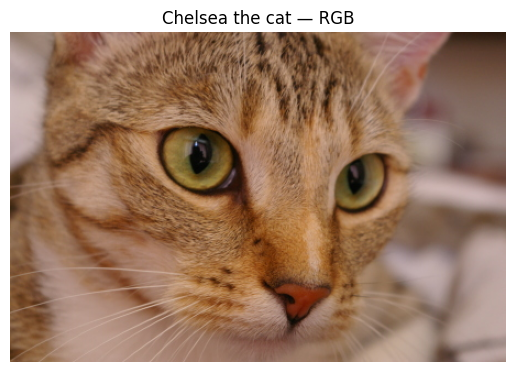

In [45]:
_ = plt.imshow(cat)
_ = plt.title("Chelsea the cat — RGB")
_ = plt.axis("off")

In [46]:
# Mean of the 3 channels gives a rough grayscale
cat_gray = cat.mean(axis=2)

print(cat_gray.shape)   # (300, 451) — no channel dimension anymore
print(cat_gray.dtype)   # float64 now, values are 0.0–255.0

(300, 451)
float64


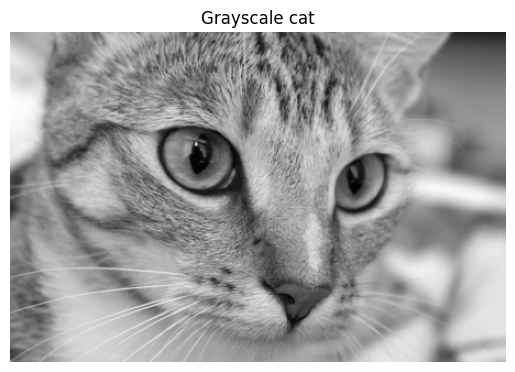

In [47]:
# cmap="gray" is important — without it matplotlib adds color
_ = plt.imshow(cat_gray, cmap="gray")
_ = plt.title("Grayscale cat")
_ = plt.axis("off")

(2, 2, 3)

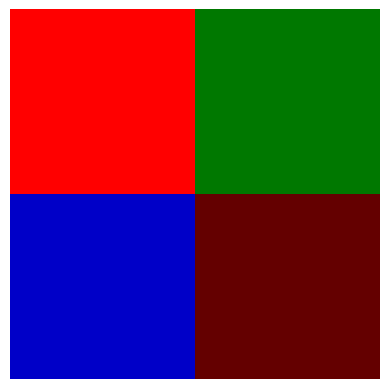

In [48]:
img = np.array([
    [[255, 0, 0], [0, 120, 0]],
    [[0, 0, 200], [100, 0, 0]],
])

img.shape
_ = plt.imshow(img)
_ = plt.axis("off")

array([[85.        , 40.        ],
       [66.66666667, 33.33333333]])

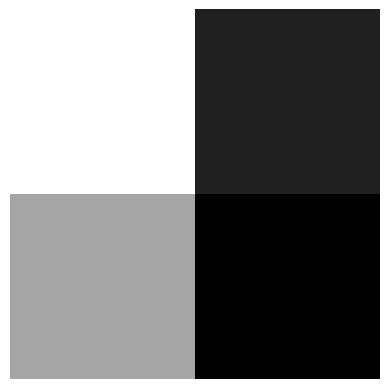

In [49]:
img_gray = img.mean(axis=2)
img_gray
_ = plt.imshow(img_gray, cmap='gray')
_ = plt.axis('off')

array([[122, 122, 120, 120, 120],
       [125, 124, 122, 121, 121],
       [128, 127, 125, 124, 124],
       [132, 130, 128, 128, 126],
       [134, 132, 131, 130, 128]])

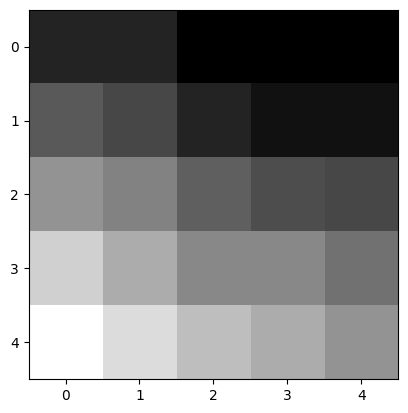

In [50]:
patch = cat_gray[:5, :5]
patch.astype(int)
_ = plt.imshow(patch, cmap='gray')

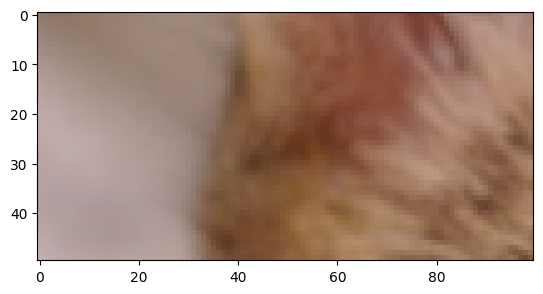

In [51]:
patch = cat[:50, :100]
# patch.astype(int)
_ = plt.imshow(patch, cmap='gray')

(512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

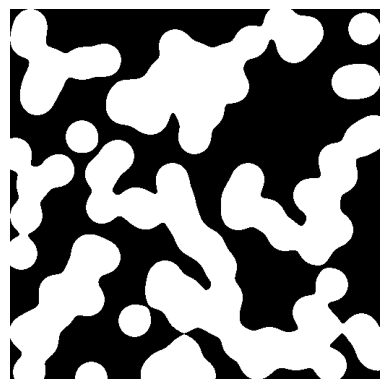

In [52]:
# Try any of these:
img = data.camera()      # grayscale cameraman photo — already grayscale, shape (512,512)
img = data.coins()       # grayscale coins on a surface
img = data.astronaut()   # RGB astronaut photo
img = data.binary_blobs()
# img = data.coffee()      # RGB coffee cup

print(img.shape)
plt.imshow(img, cmap="gray")   # add cmap="gray" only if it's grayscale
plt.axis('off')

In [53]:
from torchvision import datasets

# This downloads MNIST to a folder called 'data' in your current directory
# First time: downloads ~11MB. After that it loads from disk.
mnist_train = datasets.MNIST(root='./data', train=True, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, download=True)

print(len(mnist_train))  # 60000 training images
print(len(mnist_test))   # 10000 test images

60000
10000


In [54]:
image, label = mnist_train[0]   # image is a PIL Image object, label is an int

print(type(image))   # <class 'PIL.Image.Image'>
print(label)         # the digit — e.g. 5
print(image.size)    # (28, 28) — PIL reports (Width, Height)

<class 'PIL.Image.Image'>
5
(28, 28)


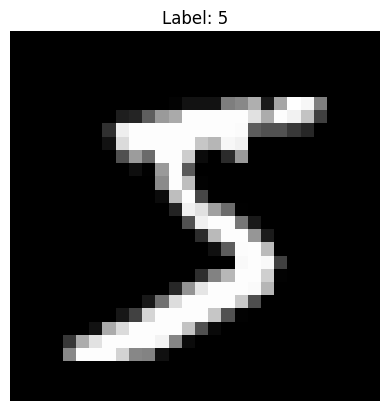

In [55]:
_ = plt.imshow(image, cmap="gray")
_ = plt.title(f"Label: {label}")
_ = plt.axis("off")

In [56]:
img_array = np.array(image)

print(img_array.shape)   # (28, 28) — no channel dimension, it's grayscale
print(img_array.dtype)   # uint8
print(img_array.min(), img_array.max())   # mostly 0s, max around 255

(28, 28)
uint8
0 255


In [57]:
for row in img_array:
  print(''.join(map(lambda x: f'{x:3d}', row)))

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

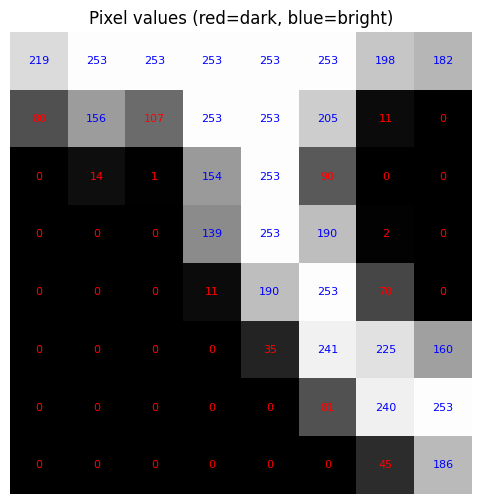

In [58]:
patch = img_array[8:16, 8:16]   # 8x8 patch from the middle where the digit is

_ = plt.figure(figsize=(6, 6))
_ = plt.imshow(patch, cmap="gray", vmin=0, vmax=255)

for i in range(patch.shape[0]):
  for j in range(patch.shape[1]):
    _ = plt.text(j, i, str(patch[i, j]),
                 ha="center", va="center",
                 color="red" if patch[i, j] < 128 else "blue",
                 fontsize=8)

_ = plt.title("Pixel values (red=dark, blue=bright)")
_ = plt.axis("off")

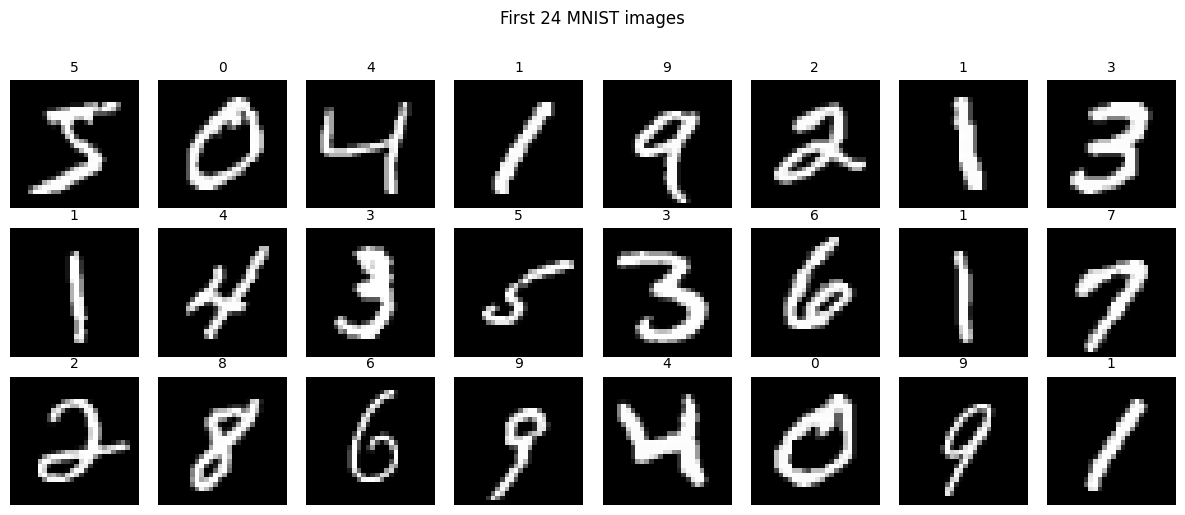

In [59]:
fig, axes = plt.subplots(3, 8, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
  image, label = mnist_train[i]
  _ = ax.imshow(image, cmap="gray")
  _ = ax.set_title(str(label), fontsize=10)
  _ = ax.axis("off")

_ = plt.suptitle("First 24 MNIST images", y=1.02)
_ = plt.tight_layout()

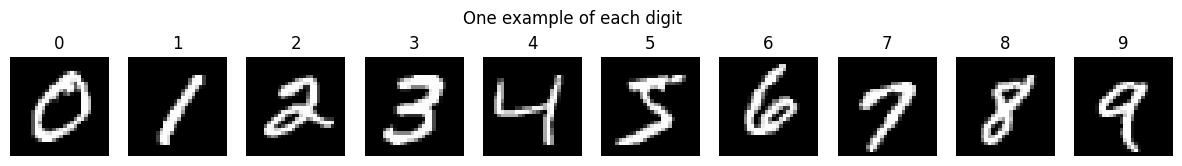

In [60]:
# Find one example of each digit 0-9
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
found = {}

for image, label in mnist_train:
  if label not in found:
    found[label] = image
  if len(found) == 10:
    break

for digit in range(10):
  _ = axes[digit].imshow(found[digit], cmap="gray")
  _ = axes[digit].set_title(str(digit))
  _ = axes[digit].axis("off")

_ = plt.suptitle("One example of each digit")

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MnistCNN(nn.Module):
  def __init__(self):
    super().__init__()
    # Feature extractor
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # Classifier
    self.fc1 = nn.Linear(64 * 12 * 12, 128)
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = F.relu(self.conv1(x))   # (1,1,28,28) → (1,32,26,26)
    x = F.relu(self.conv2(x))   # (1,32,26,26) → (1,64,24,24)
    x = self.pool(x)            # (1,64,24,24) → (1,64,12,12)
    x = x.flatten(start_dim=1)  # (1,64,12,12) → (1,9216)
    x = F.relu(self.fc1(x))    # (1,9216) → (1,128)
    x = self.fc2(x)            # (1,128) → (1,10)
    return x


model = MnistCNN()
print(model)

MnistCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [62]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")

Total parameters:     1,199,882
Trainable parameters: 1,199,882


In [63]:
for name, param in model.named_parameters():
  print(f"{name:20s}  shape: {str(param.shape):30s}  values: {param.numel():,}")

conv1.weight          shape: torch.Size([32, 1, 3, 3])       values: 288
conv1.bias            shape: torch.Size([32])                values: 32
conv2.weight          shape: torch.Size([64, 32, 3, 3])      values: 18,432
conv2.bias            shape: torch.Size([64])                values: 64
fc1.weight            shape: torch.Size([128, 9216])         values: 1,179,648
fc1.bias              shape: torch.Size([128])               values: 128
fc2.weight            shape: torch.Size([10, 128])           values: 1,280
fc2.bias              shape: torch.Size([10])                values: 10


In [64]:
# conv1 has 32 kernels, each 1×3×3. Let's look at the first one.
w = model.conv1.weight.data

print(w.shape)       # (32, 1, 3, 3) — 32 kernels, 1 input channel, 3×3
print(w[0])          # the first kernel — 9 random-ish small numbers
print(w[0].min().item(), w[0].max().item())

torch.Size([32, 1, 3, 3])
tensor([[[ 0.0442,  0.2121,  0.1740],
         [-0.0668, -0.2366, -0.2504],
         [-0.2685, -0.1952, -0.2717]]])
-0.27171775698661804 0.21208277344703674


Text(0.5, 1.01, 'conv1 kernels — random (untrained)')

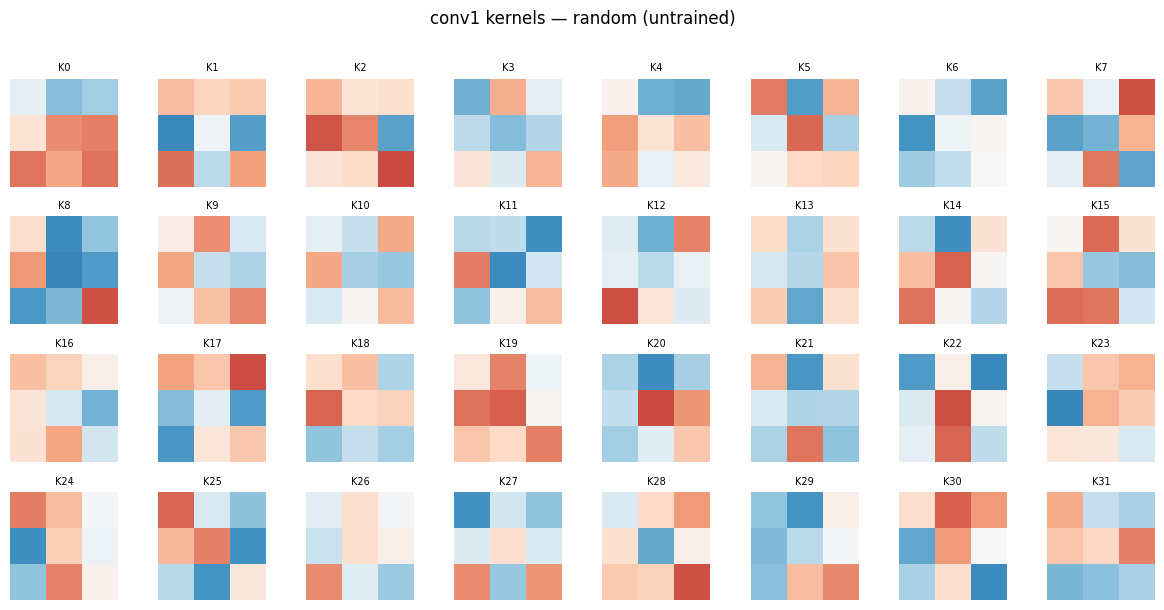

In [65]:
# Visualize all 32 kernels as small grids
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  kernel = w[i, 0].detach().numpy()  # shape (3,3)
  _ = ax.imshow(kernel, cmap="RdBu", vmin=-0.5, vmax=0.5)
  _ = ax.axis("off")
  _ = ax.set_title(f"K{i}", fontsize=7)

plt.suptitle("conv1 kernels — random (untrained)", y=1.01)
plt.tight_layout()

In [66]:
from torchvision import datasets
import numpy as np

mnist_train = datasets.MNIST(root='./data', train=True, download=True)
image, true_label = mnist_train[0]

# Convert PIL image → tensor with the right shape
img_tensor = torch.tensor(np.array(image), dtype=torch.float32)
img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)  # (28,28) → (1,1,28,28)
img_tensor = img_tensor / 255.0                     # normalize to 0–1

print(img_tensor.shape)   # (1, 1, 28, 28)
print(f"True label: {true_label}")

torch.Size([1, 1, 28, 28])
True label: 5


In [67]:
# Run it through the untrained model
_ = model.eval()
with torch.no_grad():
  output = model(img_tensor)

print("Raw output (logits):")
print(output)
print(f"\nShape: {output.shape}")  # (1, 10)

Raw output (logits):
tensor([[ 0.0125, -0.0837,  0.0408,  0.0347,  0.0065,  0.0226,  0.0344, -0.1705,
         -0.0393, -0.0507]])

Shape: torch.Size([1, 10])


In [68]:
probabilities = F.softmax(output, dim=1)
predicted_digit = output.argmax(dim=1).item()

print("Probabilities per digit:")
for digit, prob in enumerate(probabilities[0]):
  bar = "█" * int(prob.item() * 40)
  print(f"  {digit}: {prob.item():.4f}  {bar}")

print(f"\nPredicted: {predicted_digit}")
print(f"Actual:    {true_label}")
print(f"Correct?   {predicted_digit == true_label}")

Probabilities per digit:
  0: 0.1030  ████
  1: 0.0936  ███
  2: 0.1060  ████
  3: 0.1053  ████
  4: 0.1024  ████
  5: 0.1041  ████
  6: 0.1053  ████
  7: 0.0858  ███
  8: 0.0978  ███
  9: 0.0967  ███

Predicted: 2
Actual:    5
Correct?   False


In [69]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transform: convert PIL image to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),           # PIL (28,28) → tensor (1,28,28), values 0–1
    transforms.Normalize((0.1307,), (0.3081,))  # mean and std of MNIST dataset
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training batches:  {len(train_loader)}")   # 60000 / 64 = 938 batches
print(f"Test batches:      {len(test_loader)}")     # 10000 / 64 = 157 batches

Training batches:  938
Test batches:      157


In [70]:
import torch.optim as optim

model = MnistCNN()  # fresh untrained model

loss_fn = nn.CrossEntropyLoss()   # standard for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [71]:
def train_one_epoch(model, loader, optimizer, loss_fn, epoch):
  model.train()
  total_loss = 0
  correct = 0

  for batch_idx, (images, labels) in enumerate(loader):
    optimizer.zero_grad()           # clear old gradients
    output = model(images)          # forward pass
    loss = loss_fn(output, labels)  # compute loss
    loss.backward()                 # backprop — compute gradients
    optimizer.step()                # update weights

    total_loss += loss.item()
    correct += (output.argmax(dim=1) == labels).sum().item()

    if batch_idx % 200 == 0:
      print(f"  Epoch {epoch} | Batch {batch_idx:4d}/{len(loader)} | Loss: {loss.item():.4f}")

  avg_loss = total_loss / len(loader)
  accuracy = correct / len(loader.dataset) * 100
  return avg_loss, accuracy

In [72]:
def evaluate(model, loader, loss_fn):
  model.eval()
  total_loss = 0
  correct = 0

  with torch.no_grad():               # no gradients needed for evaluation
    for images, labels in loader:
      output = model(images)
      loss = loss_fn(output, labels)
      total_loss += loss.item()
      correct += (output.argmax(dim=1) == labels).sum().item()

  avg_loss = total_loss / len(loader)
  accuracy = correct / len(loader.dataset) * 100
  return avg_loss, accuracy

In [73]:
NUM_EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
  print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
  print("-" * 40)

  train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, epoch)
  test_loss,  test_acc = evaluate(model, test_loader, loss_fn)

  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["test_loss"].append(test_loss)
  history["test_acc"].append(test_acc)

  print(f"\n  Train — loss: {train_loss:.4f}  accuracy: {train_acc:.2f}%")
  print(f"  Test  — loss: {test_loss:.4f}  accuracy: {test_acc:.2f}%")


Epoch 1/5
----------------------------------------
  Epoch 1 | Batch    0/938 | Loss: 2.3105
  Epoch 1 | Batch  200/938 | Loss: 0.1427
  Epoch 1 | Batch  400/938 | Loss: 0.0223
  Epoch 1 | Batch  600/938 | Loss: 0.0272
  Epoch 1 | Batch  800/938 | Loss: 0.0603

  Train — loss: 0.1246  accuracy: 96.21%
  Test  — loss: 0.0444  accuracy: 98.57%

Epoch 2/5
----------------------------------------
  Epoch 2 | Batch    0/938 | Loss: 0.0031
  Epoch 2 | Batch  200/938 | Loss: 0.0182
  Epoch 2 | Batch  400/938 | Loss: 0.0205
  Epoch 2 | Batch  600/938 | Loss: 0.0110
  Epoch 2 | Batch  800/938 | Loss: 0.0273

  Train — loss: 0.0377  accuracy: 98.79%
  Test  — loss: 0.0390  accuracy: 98.73%

Epoch 3/5
----------------------------------------
  Epoch 3 | Batch    0/938 | Loss: 0.0473
  Epoch 3 | Batch  200/938 | Loss: 0.0218
  Epoch 3 | Batch  400/938 | Loss: 0.0804
  Epoch 3 | Batch  600/938 | Loss: 0.0004
  Epoch 3 | Batch  800/938 | Loss: 0.0251

  Train — loss: 0.0219  accuracy: 99.31%
  Test

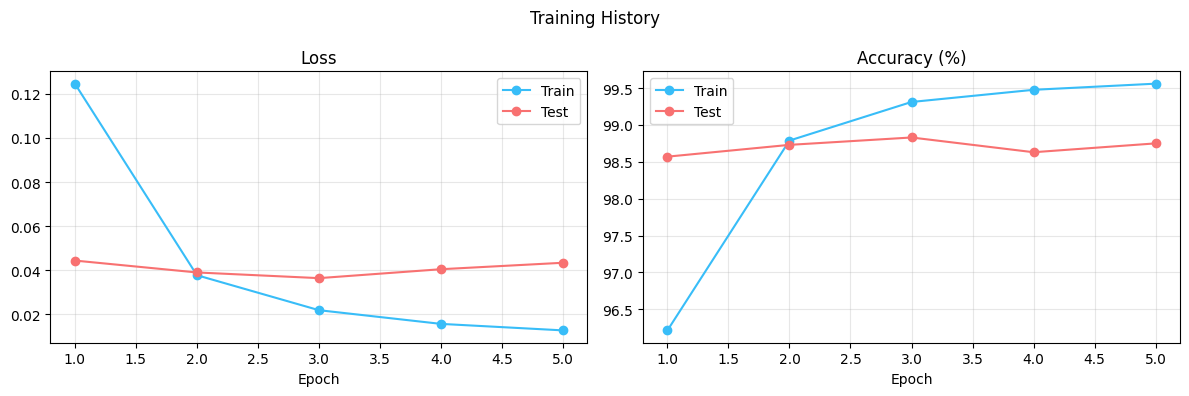

In [79]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

_ = ax1.plot(epochs, history["train_loss"], "o-", label="Train", color="#38bdf8")
_ = ax1.plot(epochs, history["test_loss"],  "o-", label="Test",  color="#f87171")
_ = ax1.set_title("Loss")
_ = ax1.set_xlabel("Epoch")
_ = ax1.legend()
_ = ax1.grid(alpha=0.3)

_ = ax2.plot(epochs, history["train_acc"], "o-", label="Train", color="#38bdf8")
_ = ax2.plot(epochs, history["test_acc"],  "o-", label="Test",  color="#f87171")
_ = ax2.set_title("Accuracy (%)")
_ = ax2.set_xlabel("Epoch")
_ = ax2.legend()
_ = ax2.grid(alpha=0.3)

_ = plt.suptitle("Training History")
_ = plt.tight_layout()

Probabilities:
  0: 0.0000  
  1: 0.0000  
  2: 0.0000  
  3: 0.0000  
  4: 0.0000  
  5: 0.0000  
  6: 0.0000  
  7: 1.0000  ██████████████████████████████████████████████████
  8: 0.0000  
  9: 0.0000  


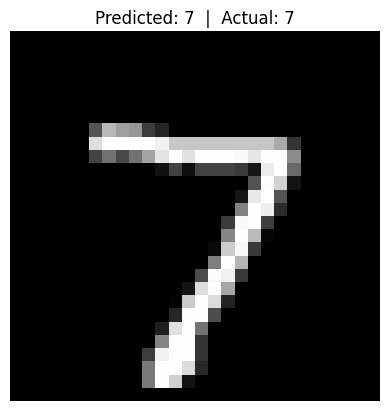

In [81]:
image, true_label = test_dataset[0]      # use test set now
img_tensor = image.unsqueeze(0)          # (1,28,28) → (1,1,28,28)

_ = model.eval()
with torch.no_grad():
  output = model(img_tensor)

probs = F.softmax(output, dim=1)
predicted = output.argmax(dim=1).item()

_ = plt.imshow(image.squeeze(), cmap="gray")
_ = plt.title(f"Predicted: {predicted}  |  Actual: {true_label}")
_ = plt.axis("off")

print("Probabilities:")
for digit, prob in enumerate(probs[0]):
  bar = "█" * int(prob.item() * 50)
  print(f"  {digit}: {prob.item():.4f}  {bar}")